<a href="https://colab.research.google.com/github/Akintomide2002/Predicting-Titanic-Survivors---Data-Science-Project/blob/main/Predicting_Titanic_Survivors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Descripe: This program predicts if a passenger will survive on the titanic

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Load the Data Set
titanic = sns.load_dataset('titanic')

#Print the first 10 rows of the data
titanic.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [ ]:
#Count the number of rolls and columns in the dataset

titanic.shape

(891, 15)

In [ ]:
#Get some statistics

titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
#Get a count of the number of the survivors
titanic['survived'].value_counts()

,count
survived,
0,549
1,342


<Axes: ylabel='count'>

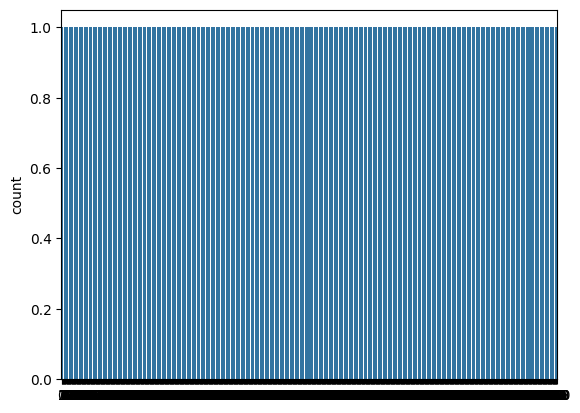

In [ ]:
#Visualize the count of survivors
sns.countplot ( titanic['survived'] )

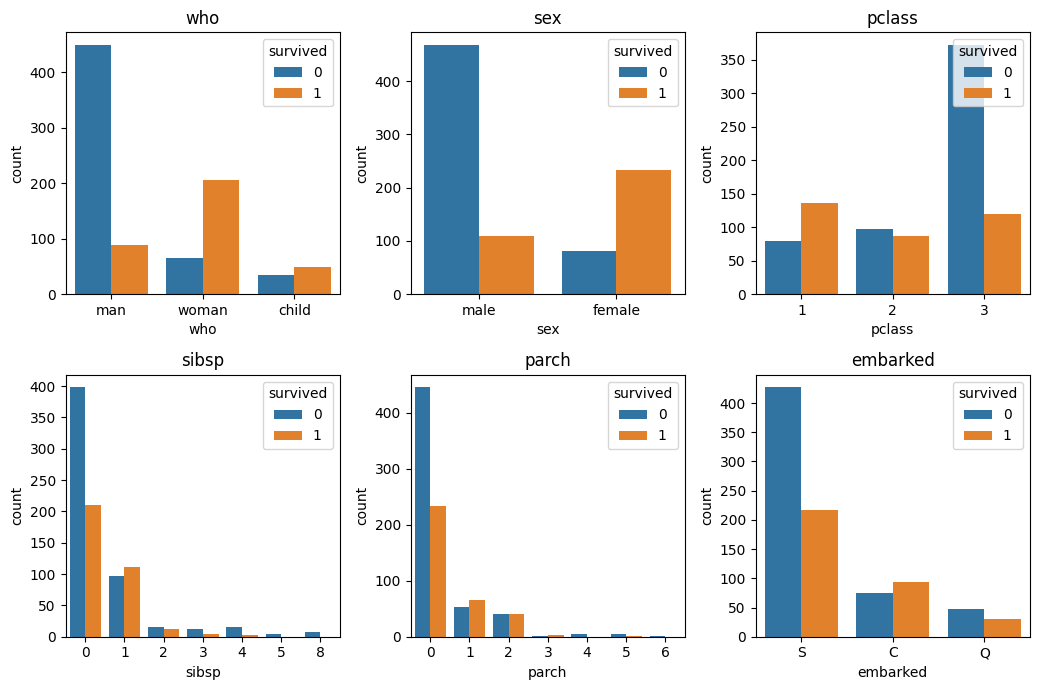

In [ ]:
#Visualize the count for survivors for column 'who', 'sex', 'pclass', 'sibsp', 'parch', 'embarked'

cols = [ 'who', 'sex', 'pclass', 'sibsp', 'parch', 'embarked']

n_rows = 2
n_cols = 3

#The subplot grid and figure size of each graph
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.5) )
for r in range(0, n_rows):
  for c in range(0, n_cols):

         i = r*n_cols + c #index to go through the number of columns
         ax = axs[r][c] #where to position each sub plot
         sns.countplot(x=titanic[cols[i]], hue=titanic['survived'], ax=ax)
         ax.set_title(cols[i])
         ax.legend(title='survived', loc = 'upper right')

plt.tight_layout()

In [ ]:
#Look at the survival rate by sex
titanic.groupby('sex')[['survived']].mean()

,survived
sex,
female,0.742038
male,0.188908


In [ ]:
#Look at the survival rate by sex and class

titanic.pivot_table('survived', index='sex', columns='class')

/tmp/ipykernel_10334/477439204.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', index='sex', columns='class')


class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


/tmp/ipykernel_10334/3459619761.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', index='sex', columns='class').plot()


<Axes: xlabel='sex'>

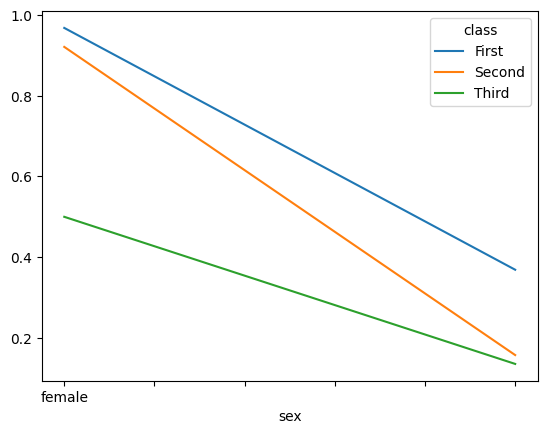

In [ ]:
#Look at the survival rate by sex and class visually

titanic.pivot_table('survived', index='sex', columns='class').plot()

<Axes: xlabel='class', ylabel='survived'>

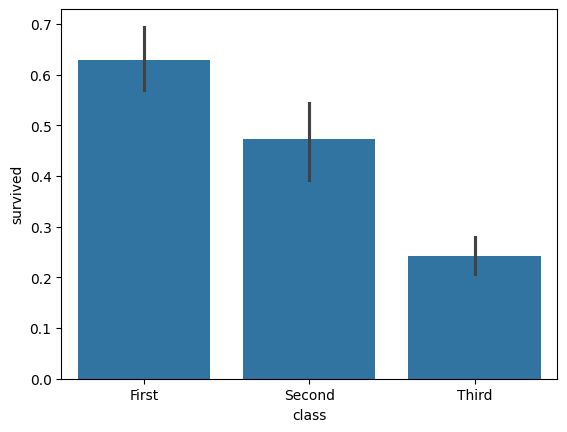

In [ ]:
#Plot the survuival rate of each class
sns.barplot(x='class', y='survived', data=titanic)

In [ ]:
#Survival rate by age, sex, and class
age = pd.cut(titanic['age'], [0, 18, 80])
titanic.pivot_table ('survived', ['sex', age], 'class')

/tmp/ipykernel_10334/85035958.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table ('survived', ['sex', age], 'class')


class               First    Second     Third
sex    age                                   
female (0, 18]   0.909091  1.000000  0.511628
       (18, 80]  0.972973  0.900000  0.423729
male   (0, 18]   0.800000  0.600000  0.215686
       (18, 80]  0.375000  0.071429  0.133663

/tmp/ipykernel_10334/1861680167.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table ('survived', ['sex', age], 'class').plot()


<Axes: xlabel='sex,age'>

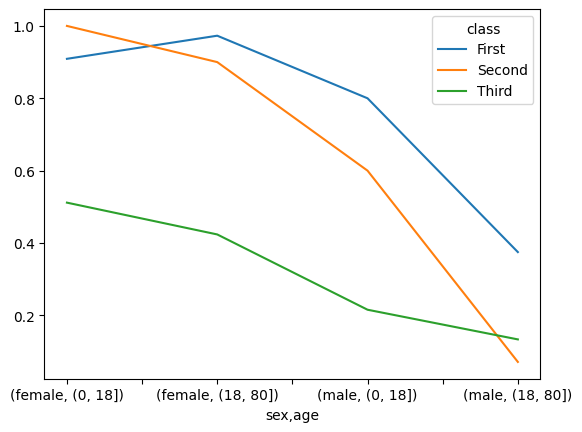

In [ ]:
#Survival rate by age, sex, and class visually
age = pd.cut(titanic['age'], [0, 18, 80])
titanic.pivot_table ('survived', ['sex', age], 'class').plot()

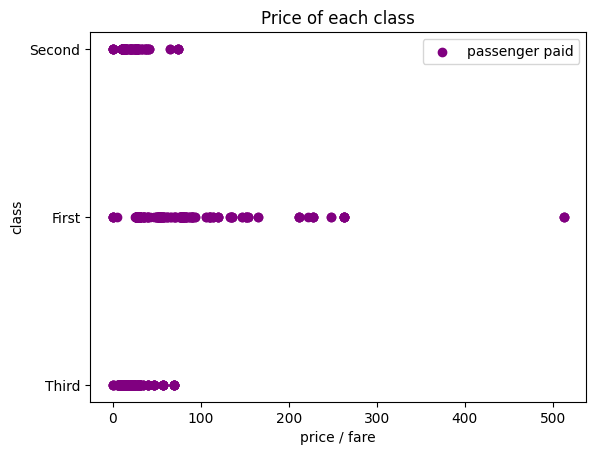

In [ ]:
#Plot the prices paid for each class
plt.scatter(titanic ['fare'], titanic ['class'], color = 'purple', label = 'passenger paid')
plt.ylabel ('class')
plt.xlabel ('price / fare')
plt.title ('Price of each class')
plt.legend()
plt.show()


In [ ]:
#Count the values in each column
titanic.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
#Look at all of the values in each colomn and get a count
for val in titanic:
  print(titanic[val].value_counts())
  print()

survived
0    549
1    342
Name: count, dtype: int64

pclass
3    491
1    216
2    184
Name: count, dtype: int64

sex
male      577
female    314
Name: count, dtype: int64

age
24.00    30
22.00    27
18.00    26
28.00    25
30.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

sibsp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
           ..
13.8583     1
50.4958     1
5.0000      1
9.8458      1
10.5167     1
Name: count, Length: 248, dtype: int64

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

class
Third     491
First     216
Second    184
Name: count, dtype: int64

who
man      537
woman    271
child     83
Name: count, dtype: int64

adult_male
True     537
False    354
Name: count, dt

In [ ]:
#Drop the columns
titanic = titanic.drop(['deck', 'embark_town', 'alive', 'class', 'who', 'alone', 'adult_male' ], axis = 1, errors='ignore')

In [ ]:
#Remove the rows with missing values
titanic = titanic.dropna(subset = ['embarked', 'age'])

In [ ]:
#Count the new number of roles and columns in the data set
titanic.shape

(712, 8)

In [ ]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()

#Encode the sex column
titanic['sex'] = labelencoder.fit_transform(titanic['sex'].values).astype('int64')
#Encode the embarked column
titanic['embarked'] = labelencoder.fit_transform(titanic['embarked'].values).astype('int64')

In [ ]:
#Print the unique values in the columns
print(titanic['sex'].unique())
print(titanic ['embarked'].unique())

[1 0]
[2 0 1]


In [ ]:
titanic.dtypes

,0
survived,int64
pclass,int64
sex,int64
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,int64


In [ ]:
#Split the data into independent 'X' and 'Y' variables
X = titanic.iloc[:, 1:8].values
Y = titanic.iloc[:, 0].values


In [ ]:
#Split the dataset into 80% training and 20% testing
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(x_train)
X_test = sc.transform(x_test) # Corrected to transform x_test using the scaler fitted on x_train

In [ ]:
#Create a function with many machine learning models
def models(X_train, Y_train):

  #Use logistic Regression
  from sklearn.linear_model import LogisticRegression
  log = LogisticRegression(random_state=0)
  log.fit(X_train, Y_train) # Corrected to use scaled X_train

  #Use kNeighbors
  from sklearn.neighbors import KNeighborsClassifier
  knn = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p=2)
  knn.fit(X_train, Y_train)

  #Use SVC (linear kernel)
  from sklearn.svm import SVC
  svc_lin = SVC(kernel = 'linear', random_state = 0) # Defined svc_lin
  svc_lin.fit(X_train, Y_train)

  #Use SVC (RBF kernel)
  svc_rbf = SVC(kernel = 'rbf', random_state = 0)
  svc_rbf.fit(X_train, Y_train)

  #Use GaussianNB
  from sklearn.naive_bayes import GaussianNB
  gauss = GaussianNB()
  gauss.fit(X_train, Y_train)

  #Use Decision Tree
  from sklearn.tree import DecisionTreeClassifier
  tree = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
  tree.fit(X_train, Y_train)

  #Use the RandomForestClassifier
  from sklearn.ensemble import RandomForestClassifier
  forest = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
  forest.fit(X_train, Y_train)

  #Print the training accuracy for each model
  print('[0]Logistic Regression Training Accuracy: ', log.score(X_train, Y_train))
  print('[1]K Neighbors Training Accuracy: ', knn.score(X_train, Y_train))
  print('[2]SVC Linear Training Accuracy: ', svc_lin.score(X_train, Y_train)) # Corrected print statement
  print('[3]SVC RBF Training Accuracy: ', svc_rbf.score(X_train, Y_train))
  print('[4]Gaussian NB Training Accuracy: ', gauss.score(X_train, Y_train))
  print('[5]Decision Tree Training Accuracy: ', tree.score(X_train, Y_train))
  print('[6]Random Forest Training Accuracy: ', forest.score(X_train, Y_train))

  return log, knn, svc_lin, svc_rbf, gauss, tree, forest # Returned svc_lin

In [ ]:
#Get and train all of the models
model = models(X_train, y_train)

[0]Logistic Regression Training Accuracy:  0.7978910369068541
[1]K Neighbors Training Accuracy:  0.8664323374340949
[2]SVC Linear Training Accuracy:  0.7768014059753954
[3]SVC RBF Training Accuracy:  0.8506151142355008
[4]Gaussian NB Training Accuracy:  0.8031634446397188
[5]Decision Tree Training Accuracy:  0.9929701230228472
[6]Random Forest Training Accuracy:  0.9753954305799648


In [ ]:
#Show the confusion matrix and accuracy on all of the models on the test data
from sklearn.metrics import confusion_matrix

# Re-initialize 'model' if it's not defined (e.g., due to kernel restart or skipped cell execution)
# This assumes 'models', 'X_train', and 'y_train' are accessible from previous cells.
if 'model' not in locals() and 'model' not in globals():
    model = models(X_train, y_train)

for i in range( len(model) ):
  # Get predictions for the current model
  y_pred = model[i].predict(X_test)

  # Calculate confusion matrix for the current model
  cm = confusion_matrix(y_test, y_pred)

  # Extract TN, FP, FN, TP from the current confusion matrix
  TN, FP, FN, TP = cm.ravel()

  # Calculate accuracy for the current model
  total_predictions = (TP + TN + FN + FP)
  if total_predictions > 0:
      test_score = (TP + TN) / total_predictions
  else:
      test_score = 0.0 # Handle case of no predictions

  print(f'Model [{i}]') # Use f-string for clarity and consistency
  print('Confusion Matrix:')
  print(cm)
  print(f'Testing Accuracy = "{test_score:.4f}"') # Use f-string for easier formatting
  print()

Model [0]
Confusion Matrix:
[[73  9]
 [18 43]]
Testing Accuracy = "0.8112"

Model [1]
Confusion Matrix:
[[71 11]
 [20 41]]
Testing Accuracy = "0.7832"

Model [2]
Confusion Matrix:
[[70 12]
 [18 43]]
Testing Accuracy = "0.7902"

Model [3]
Confusion Matrix:
[[75  7]
 [22 39]]
Testing Accuracy = "0.7972"

Model [4]
Confusion Matrix:
[[69 13]
 [23 38]]
Testing Accuracy = "0.7483"

Model [5]
Confusion Matrix:
[[60 22]
 [10 51]]
Testing Accuracy = "0.7762"

Model [6]
Confusion Matrix:
[[67 15]
 [13 48]]
Testing Accuracy = "0.8042"



In [ ]:
#Get feature importance
forest = model[6]
importances = pd.DataFrame({'feature': titanic.iloc[:, 1:8].columns, 'importance': np.round(forest.feature_importances_, 3)})
importances = importances.sort_values('importance', ascending = False).set_index('feature')
importances

,importance
feature,
age,0.300
fare,0.296
sex,0.183
pclass,0.098
sibsp,0.050
parch,0.044
embarked,0.030


<Axes: xlabel='feature'>

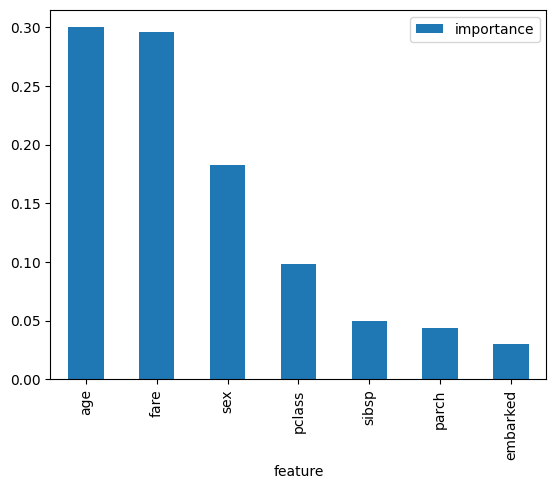

In [ ]:
#Visualize the importance
importances.plot.bar()

In [ ]:
#print the prediction of the random forest classifier
pred = model[6].predict(x_test)
print(pred)

print()

#print the actual values
print(y_test)

[0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 1 1
 1 1 0 1 1 1 1 1 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 0 0 1 1 0 0
 0 0 0 0 1 1 0 0 1 0 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1
 1 1 0 1 1 1 0 1 0 1 0 1 0 0 1 0 0 0 1 1 1 1 1 1 1 1 1 0 1 0 1 0]

[0 0 1 0 0 0 1 0 0 0 1 1 1 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 1 0 0 0 0 1 1 0 1
 1 1 1 1 1 0 0 0 0 1 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 1 0 1 1 1
 0 0 1 1 0 0 0 1 1 1 1 0 0 0 1 0 0 0 1 1 1 0 1 1 0 1 0 1 0 0 0 0 1 0 0 0 0
 1 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 1]


In [ ]:
#My Survival
my_survival = [[3, 1, 21, 0, 0, 0, 1 ]]

#Scaling my Survival
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
my_survival_scaled = sc.fit_transform(my_survival)

#Print prediction my survival using Random Forest Classifier
pred = model[6].predict(my_survival_scaled)

print(pred)

if pred == 0:
  print('Oh no! You did not make it')
else:
  print('Nice! You survived !')

[0]
Oh no! You did not make it
